Here, you can find different charts and visualizations of impact of different variables on match results and goals scored.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from io import BytesIO

import cairosvg
from PIL import Image

from scipy.stats import pearsonr

from matplotlib.offsetbox import OffsetImage, AnnotationBbox

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (12, 7)

First, we prepare the data from data_preparation.py.

In [2]:
from data_preparation.data_preparation import load_data

games, situations, players = load_data()

print(games.head())

Seasons: 2008 - 2024
Number of team codes queried: 35
Season 2008/2009: unique games found = 1429
Season 2009/2010: unique games found = 1429
Season 2010/2011: unique games found = 1425
Season 2011/2012: unique games found = 1424
Season 2012/2013: unique games found = 806
Season 2013/2014: unique games found = 1427
Season 2014/2015: unique games found = 1424
Season 2015/2016: unique games found = 1425
Season 2016/2017: unique games found = 1422
Season 2017/2018: unique games found = 1463
Season 2018/2019: unique games found = 1468
Season 2019/2020: unique games found = 1330
Season 2020/2021: unique games found = 952
Season 2021/2022: unique games found = 1504
Season 2022/2023: unique games found = 1508
Season 2023/2024: unique games found = 1511
Season 2024/2025: unique games found = 1504
Saved official NHL results cache: official_nhl_game_results.csv

PREFETCHING PLAYER STATS FOR ALL TEAM-SEASON COMBINATIONS
Total player-stat requests to process: 802
[1/802] Player stats: ANA | 2008/2

In [4]:
BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR 
LOGO_DIR = BASE_DIR / "data_preparation" / "logos"

games = pd.read_csv(
    DATA_DIR / "final_game_data.csv",
    parse_dates=["gameDate"]
)

situations = pd.read_csv(
    DATA_DIR / "final_game_situation_data.csv",
    parse_dates=["gameDate"]
)

Second, we add logos for better chart visuals. 

In [5]:
def add_logo(ax, team, x, y, zoom=0.08):

    logo_path = LOGO_DIR / f"{team}.png"

    if not logo_path.exists():
        return

    img = plt.imread(logo_path)

    imagebox = OffsetImage(img, zoom=zoom)

    ab = AnnotationBbox(
        imagebox,
        (x, y),
        frameon=False
    )

    ax.add_artist(ab)

In [6]:
def load_svg_logo(svg_path):

    png_bytes = cairosvg.svg2png(
        url=str(svg_path)
    )

    img = Image.open(
        BytesIO(png_bytes)
    )

    return np.array(img)

In [7]:
def add_logo(ax, team, x, y, zoom=0.08):

    logo_path = LOGO_DIR / f"{team}.svg"

    if not logo_path.exists():
        print(f"Missing logo: {team}")
        return

    try:

        img = load_svg_logo(logo_path)

        imagebox = OffsetImage(
            img,
            zoom=zoom
        )

        ab = AnnotationBbox(
            imagebox,
            (x, y),
            frameon=False
        )

        ax.add_artist(ab)

    except Exception as e:

        print(
            f"Could not load {team}: {e}"
        )

This first chart shows the impact of goals scored on winning.

Missing logo: ATL
Missing logo: PHX


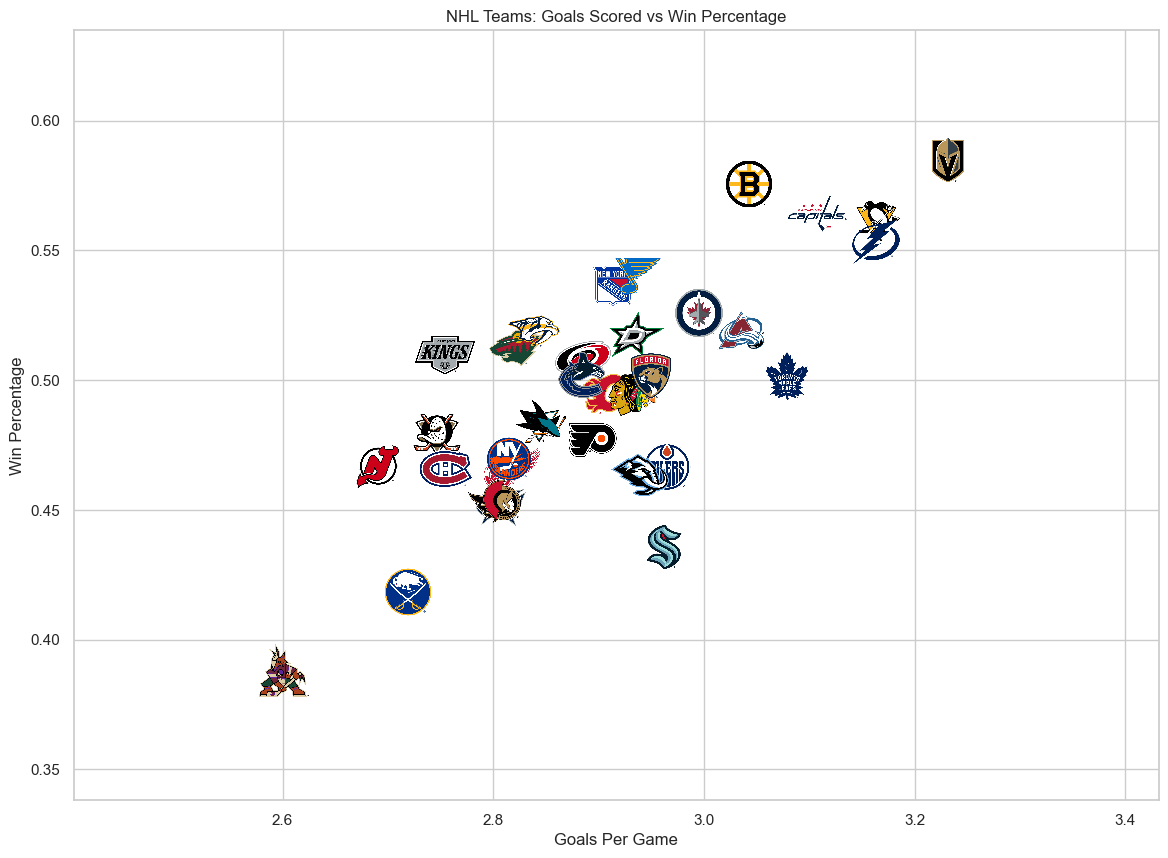

In [8]:
team_summary = (
    games
    .groupby("team_match_code")
    .agg(
        win_pct=("win", "mean"),
        goals_per_game=("game_goals_for", "mean")
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14,10))

for _, row in team_summary.iterrows():

    add_logo(
        ax,
        row["team_match_code"],
        row["goals_per_game"],
        row["win_pct"],
        zoom=0.06
    )

ax.set_xlim(
    team_summary["goals_per_game"].min() - 0.2,
    team_summary["goals_per_game"].max() + 0.2
)

ax.set_ylim(
    team_summary["win_pct"].min() - 0.05,
    team_summary["win_pct"].max() + 0.05
)

ax.set_xlabel("Goals Per Game")
ax.set_ylabel("Win Percentage")

ax.set_title(
    "NHL Teams: Goals Scored vs Win Percentage"
)

plt.show()

Now, we will visualize the importance of faceoffs percentage for goal differential by different game situations. 

In [9]:
faceoff_importance = (
    situations
    .groupby("situation")
    .apply(
        lambda x: x["faceoff_pct_100"]
        .corr(x["goal_diff"])
    )
    .reset_index(name="corr_goal_diff")
)

faceoff_importance = (
    faceoff_importance
    .sort_values(
        "corr_goal_diff",
        ascending=False
    )
)

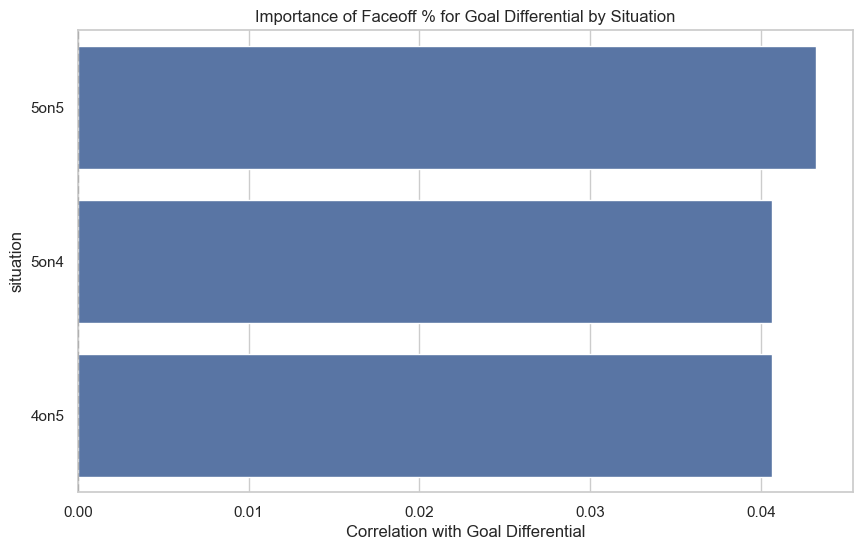

In [10]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=faceoff_importance,
    x="corr_goal_diff",
    y="situation"
)

plt.axvline(
    0,
    color="black",
    linestyle="--"
)

plt.title(
    "Importance of Faceoff % for Goal Differential by Situation"
)

plt.xlabel(
    "Correlation with Goal Differential"
)

plt.show()

Here, faceoff win percentage will be displayed against goal difference. Again, including logos. 

In [11]:
team_faceoffs = (
    situations
    .groupby("team_match_code")
    .agg(
        faceoff_pct=("faceoff_pct_100","mean"),
        goal_diff=("goal_diff","mean")
    )
    .reset_index()
)

Missing logo: ATL
Missing logo: PHX


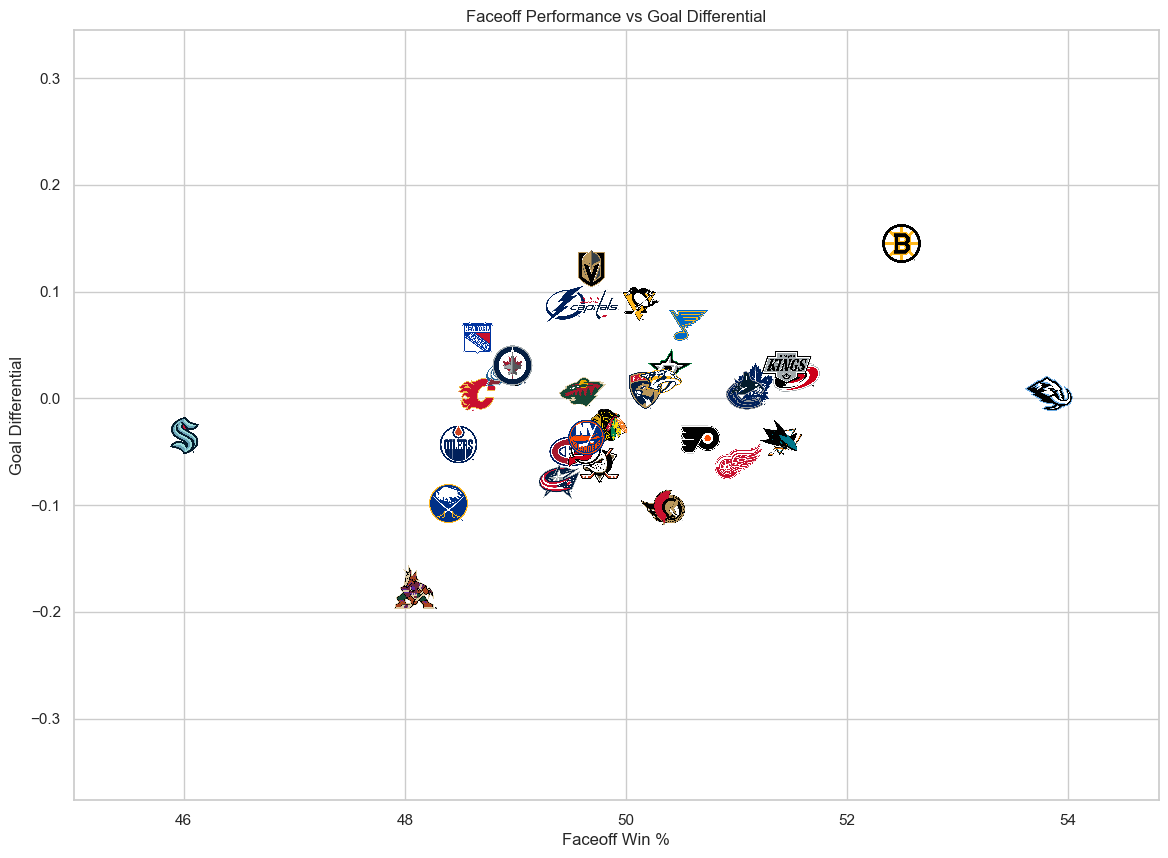

In [12]:
fig, ax = plt.subplots(figsize=(14,10))

ax.scatter(
    team_faceoffs["faceoff_pct"],
    team_faceoffs["goal_diff"],
    alpha=0
)

for _, row in team_faceoffs.iterrows():

    add_logo(
        ax,
        row["team_match_code"],
        row["faceoff_pct"],
        row["goal_diff"],
        zoom=0.05
    )

ax.set_xlim(
    team_faceoffs["faceoff_pct"].min()-1,
    team_faceoffs["faceoff_pct"].max()+1
)

ax.set_ylim(
    team_faceoffs["goal_diff"].min()-0.2,
    team_faceoffs["goal_diff"].max()+0.2
)

ax.set_xlabel("Faceoff Win %")
ax.set_ylabel("Goal Differential")

ax.set_title(
    "Faceoff Performance vs Goal Differential"
)

plt.show()

This chart tells us the importance of shots on goal within different game situations. 

In [13]:
impact_df = []

for situation in situations["situation"].unique():

    temp = situations[situations["situation"] == situation]

    impact_df.append({
        "situation": situation,
        "corr": temp["shotsOnGoalFor"].corr(temp["goal_diff"])
    })

impact_df = pd.DataFrame(impact_df)
impact_df = impact_df.sort_values("corr", ascending=False)

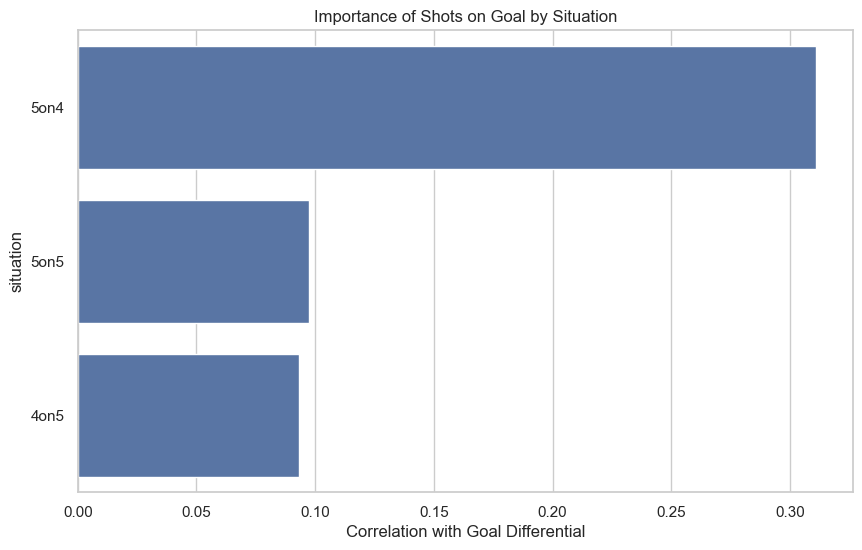

In [14]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=impact_df,
    x="corr",
    y="situation"
)

plt.title(
    "Importance of Shots on Goal by Situation"
)

plt.xlabel(
    "Correlation with Goal Differential"
)

plt.show()

Now, this unique chart shows a matrix that displays the importance of different variables in different game situations. 

In [26]:
from sklearn.ensemble import RandomForestClassifier

variables = [
    "faceoff_pct_100",
    "shotsOnGoalFor",
    "shotAttemptsFor",
    "giveawaysFor"
]

results = []

for situation in situations["situation"].unique():

    temp = situations[
        situations["situation"] == situation
    ]

    for var in variables:

        results.append({
            "Situation": situation,
            "Variable": var,
            "Correlation":
                temp[var].corr(
                    temp["goal_diff"]
                )
        })

importance_df = pd.DataFrame(results)

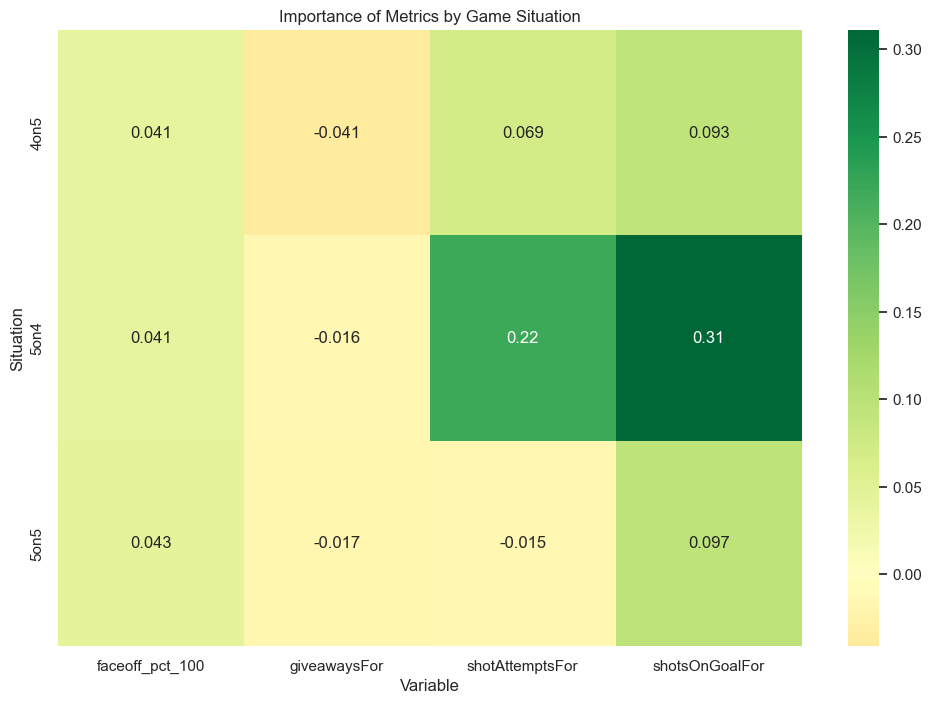

In [27]:
pivot_df = importance_df.pivot(
    index="Situation",
    columns="Variable",
    values="Correlation"
)

plt.figure(figsize=(12,8))

sns.heatmap(
    pivot_df,
    annot=True,
    cmap="RdYlGn",
    center=0
)

plt.title(
    "Importance of Metrics by Game Situation"
)

plt.show()

To the upcoming chart, we will add a trend line, so the direction of the effect is cleary visible. However, the chart itself shows the relationships between faceoff win percentage and match win percentage.

In [17]:
team_faceoff = (
    situations
    .groupby("team_match_code")
    .agg(
        faceoff_pct=("faceoff_pct_100","mean"),
        win_pct=("win","mean")
    )
    .reset_index()
)

In [28]:
from scipy.stats import linregress

x = team_faceoff["faceoff_pct"]
y = team_faceoff["win_pct"]

slope, intercept, r_value, p_value, std_err = linregress(x, y)

x_line = np.linspace(
    x.min(),
    x.max(),
    100
)

y_line = slope * x_line + intercept

ax.plot(
    x_line,
    y_line,
    linewidth=3,
    linestyle="--",
    label=f"Trend Line (R²={r_value**2:.3f})"
)

ax.legend()

Missing logo: ATL
Missing logo: PHX


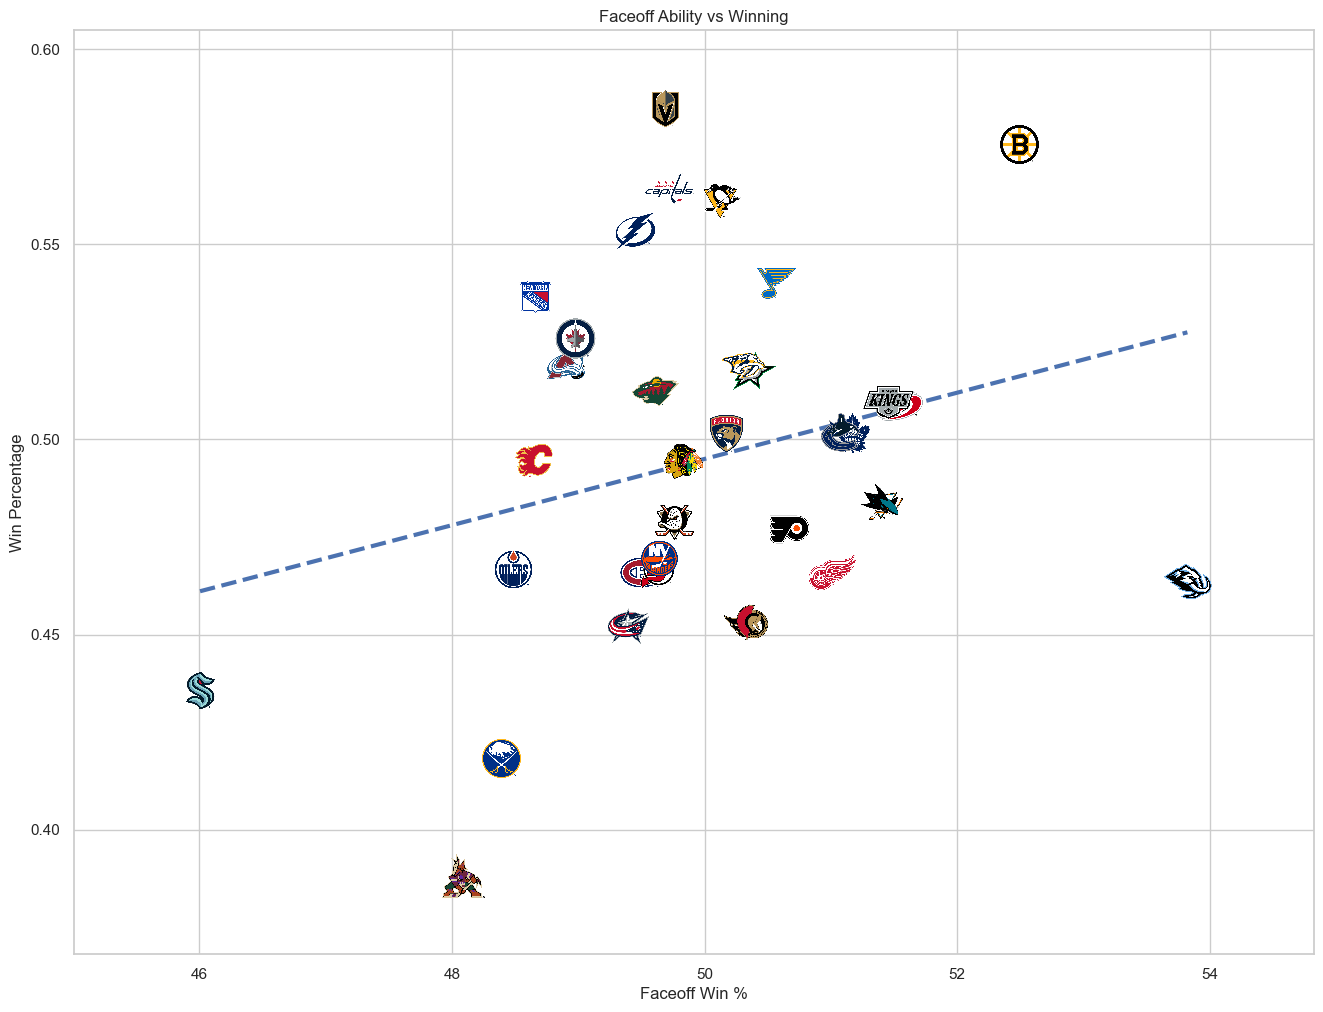

In [29]:
fig, ax = plt.subplots(figsize=(16,12))

ax.scatter(
    team_faceoff["faceoff_pct"],
    team_faceoff["win_pct"],
    alpha=0
)

x = team_faceoff["faceoff_pct"]
y = team_faceoff["win_pct"]

slope, intercept, r_value, p_value, std_err = linregress(x, y)

x_line = np.linspace(
    x.min(),
    x.max(),
    100
)

y_line = slope * x_line + intercept

ax.plot(
    x_line,
    y_line,
    linewidth=3,
    linestyle="--",
    label=f"R²={r_value**2:.3f}"
)

for _, row in team_faceoff.iterrows():

    add_logo(
        ax,
        row["team_match_code"],
        row["faceoff_pct"],
        row["win_pct"],
        zoom=0.05
    )

ax.set_xlim(
    team_faceoff["faceoff_pct"].min()-1,
    team_faceoff["faceoff_pct"].max()+1
)

ax.set_ylim(
    team_faceoff["win_pct"].min()-0.02,
    team_faceoff["win_pct"].max()+0.02
)

ax.set_xlabel("Faceoff Win %")
ax.set_ylabel("Win Percentage")

ax.set_title(
    "Faceoff Ability vs Winning"
)

plt.show()

On this chart, we can see the average amount of goals scored for and agianst with league averages. 

In [20]:
team_strength = (
    games
    .groupby("team_match_code")
    .agg(
        goals_for=("game_goals_for","mean"),
        goals_against=("game_goals_against","mean")
    )
    .reset_index()
)

Missing logo: ATL
Missing logo: PHX


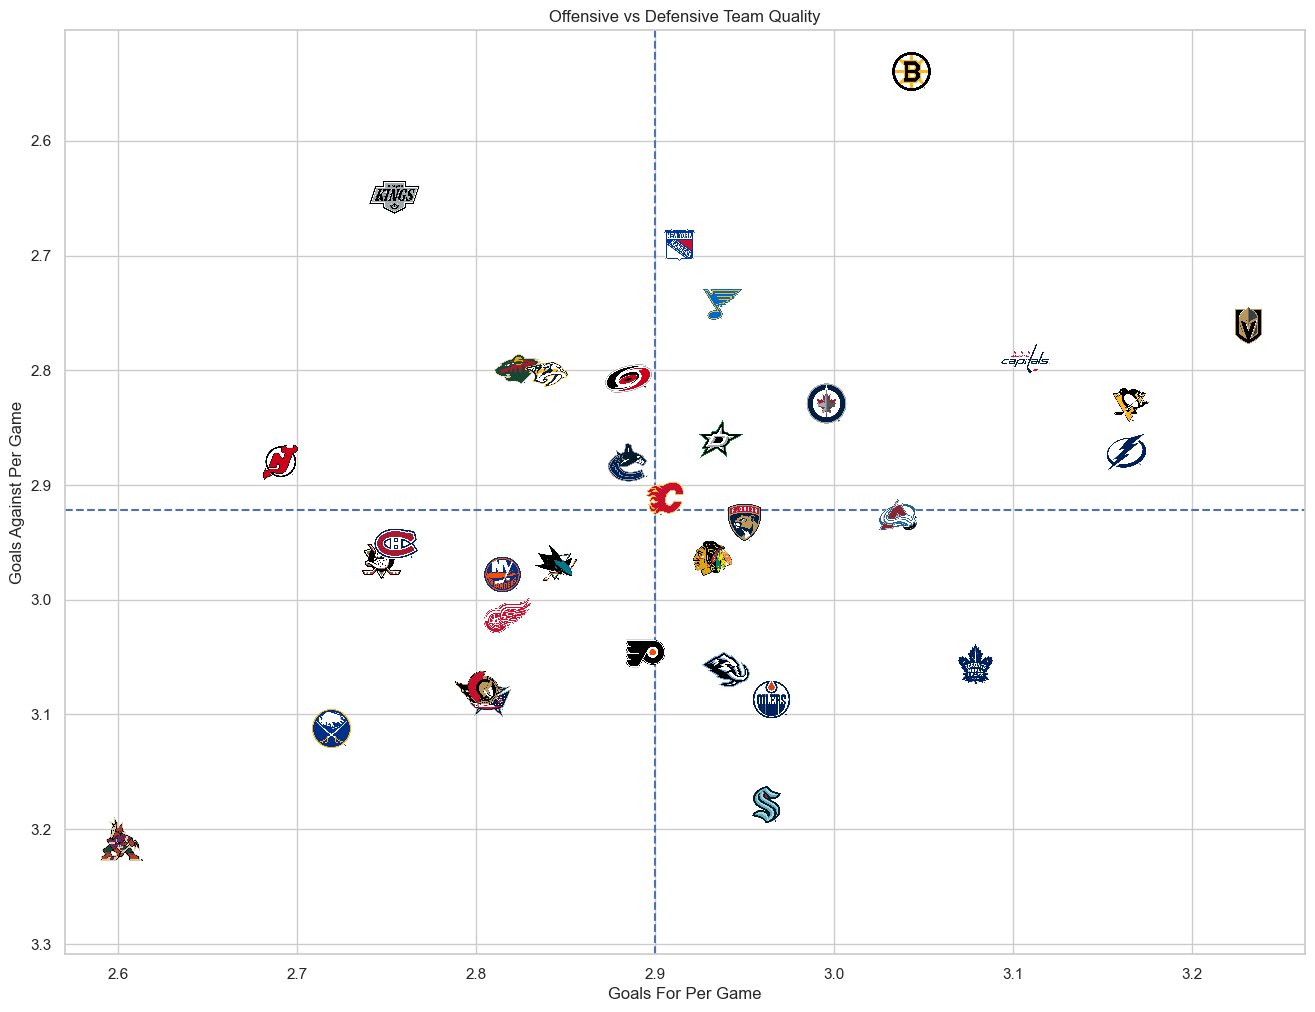

In [21]:
league_avg_for = team_strength["goals_for"].mean()
league_avg_against = team_strength["goals_against"].mean()

fig, ax = plt.subplots(figsize=(16,12))

ax.scatter(
    team_strength["goals_for"],
    team_strength["goals_against"],
    alpha=0
)

for _, row in team_strength.iterrows():

    add_logo(
        ax,
        row["team_match_code"],
        row["goals_for"],
        row["goals_against"],
        zoom=0.05
    )

ax.axvline(
    league_avg_for,
    linestyle="--"
)

ax.axhline(
    league_avg_against,
    linestyle="--"
)

ax.invert_yaxis()

ax.set_xlabel("Goals For Per Game")
ax.set_ylabel("Goals Against Per Game")

ax.set_title(
    "Offensive vs Defensive Team Quality"
)

plt.show()

This chart describes the relationship between faceoffs and scoring during powerplays.

In [22]:
pp = situations[
    situations["situation"] == "5on4"
]

pp_team = (
    pp
    .groupby("team_match_code")
    .agg(
        goals=("goalsFor","mean"),
        faceoffs=("faceoff_pct_100","mean")
    )
    .reset_index()
)

Missing logo: ATL
Missing logo: PHX


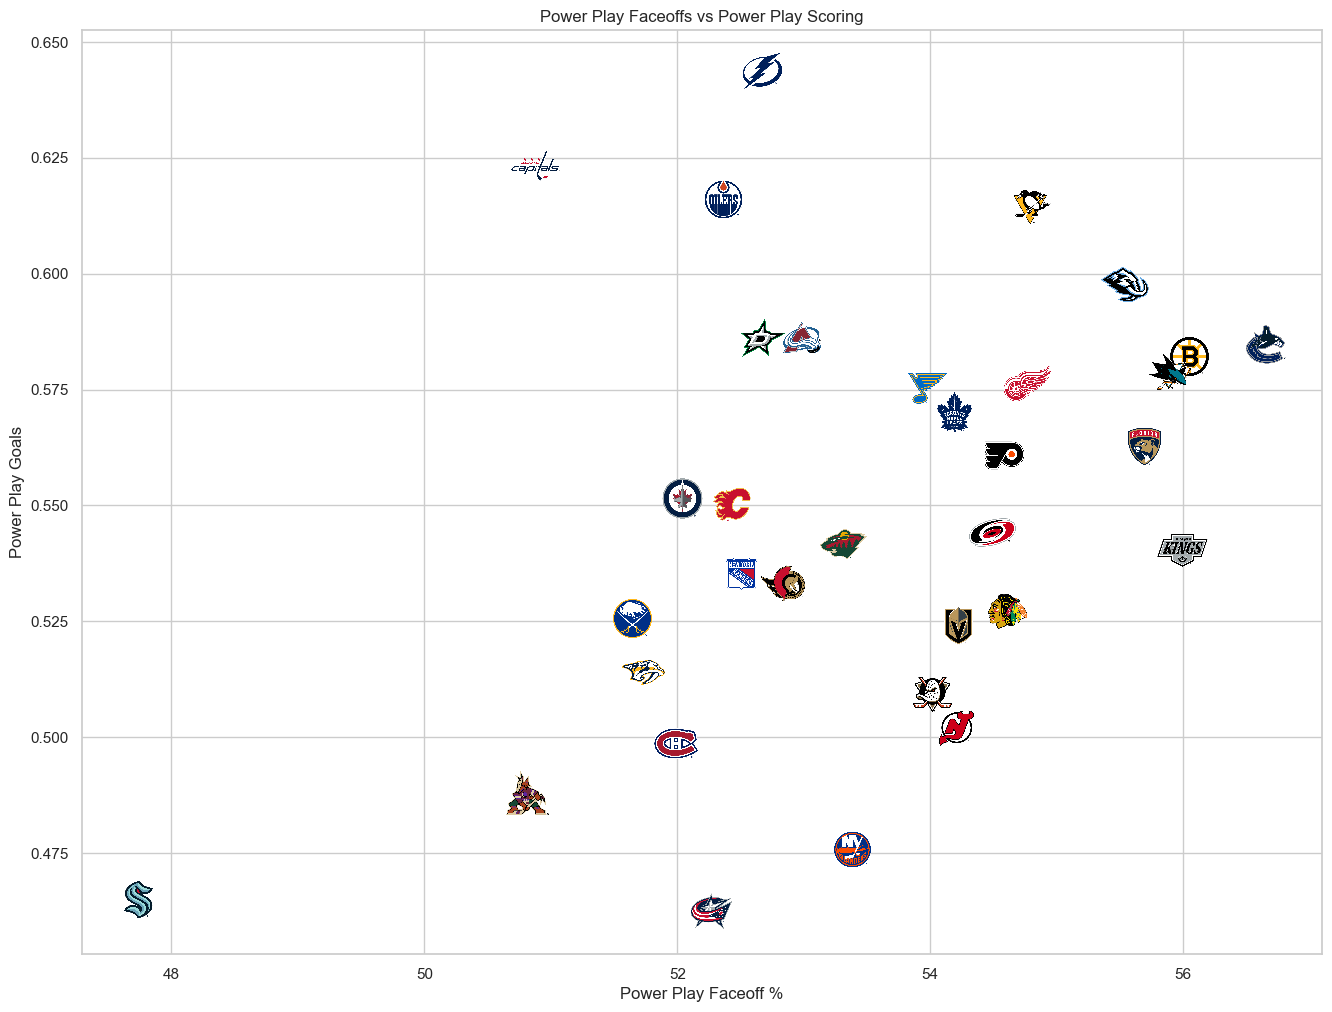

In [23]:
fig, ax = plt.subplots(figsize=(16,12))

ax.scatter(
    pp_team["faceoffs"],
    pp_team["goals"],
    alpha=0
)

for _, row in pp_team.iterrows():

    add_logo(
        ax,
        row["team_match_code"],
        row["faceoffs"],
        row["goals"],
        zoom=0.05
    )

ax.set_xlabel("Power Play Faceoff %")
ax.set_ylabel("Power Play Goals")

ax.set_title(
    "Power Play Faceoffs vs Power Play Scoring"
)

plt.show()

And the final chart shows, how different variables are important for winning. Again, our three game situations are being compared. 

In [24]:
variables = [
    "faceoff_pct_100",
    "shotsOnGoalFor",
    "shotAttemptsFor",
    "giveawaysFor"
]

importance_results = []

for situation in situations["situation"].unique():

    temp = situations[
        situations["situation"] == situation
    ].dropna()

    X = temp[variables]
    y = temp["win"]

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )

    model.fit(X, y)

    for var, imp in zip(
        variables,
        model.feature_importances_
    ):

        importance_results.append({
            "Situation": situation,
            "Variable": var,
            "Importance": imp
        })

importance_results = pd.DataFrame(
    importance_results
)

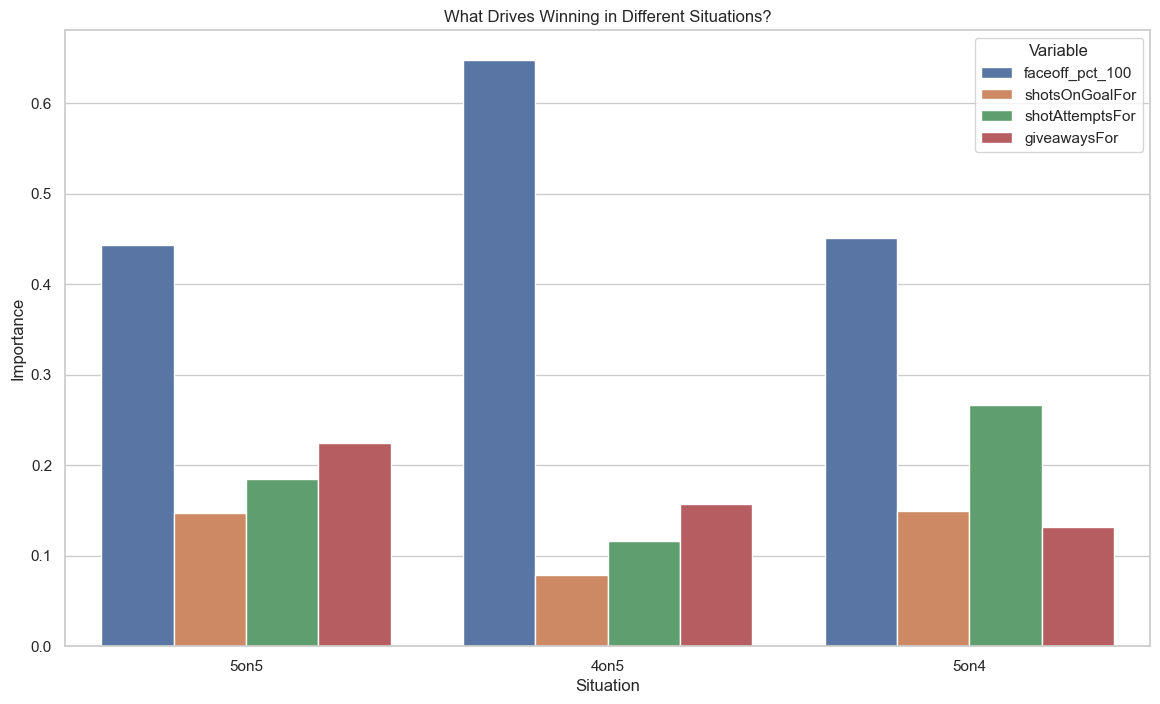

In [25]:
plt.figure(figsize=(14,8))

sns.barplot(
    data=importance_results,
    x="Situation",
    y="Importance",
    hue="Variable"
)

plt.title(
    "What Drives Winning in Different Situations?"
)

plt.show()